In [ ]:
!pip install roboflow ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which is incompatible.


In [ ]:
!nvidia-smi

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Wed Jul  1 04:26:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('DamagePackages_API'))
project = rf.workspace("bdata-497-advanced-topics-in-data-visualization").project("final-project-zseyl")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final-Project-2 in yolov11:: 100%|██████████| 5118/5118 [00:00<00:00, 7421.49it/s]


In [ ]:
import yaml

yaml_path = f"{dataset.location}/data.yaml"

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['Damaged', 'Normal'], 'roboflow': {'workspace': 'bdata-497-advanced-topics-in-data-visualization', 'project': 'final-project-zseyl', 'version': 2, 'license': 'MIT', 'url': 'https://universe.roboflow.com/bdata-497-advanced-topics-in-data-visualization/final-project-zseyl/dataset/2'}}


In [ ]:
from ultralytics import YOLO

# load pretrained YOLOv11 nano model
model = YOLO("yolo11n.pt")

# training
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,       # early stopping jika tidak ada improvement
    project="damaged_package_runs",
    name="train",
    plots=True
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Final-Project-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [ ]:
# ambil langsung dari objek 'results' hasil model.train() sebelumnya
best_model_path = results.save_dir / "weights" / "best.pt"
print("Model dipakai dari:", best_model_path)

best_model = YOLO(best_model_path)
metrics = best_model.val(data=yaml_path, split="test")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Model dipakai dari: /content/runs/detect/damaged_package_runs/train-2/weights/best.pt
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1106.9±331.0 MB/s, size: 41.4 KB)
val: Scanning /content/Final-Project-2/test/labels... 257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 257/257 2.0Kit/s 0.1s
val: New cache created: /content/Final-Project-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 4.3it/s 3.9s
                   all        257        299      0.935      0.867      0.927      0.849
               Damaged        153        153      0.936      0.951      0.965      0.904
                Normal        104        146      0.935      0.782       0.89      0.794
Speed: 2.0ms preprocess, 5.1ms inference, 0.0ms loss, 1.4ms postprocess

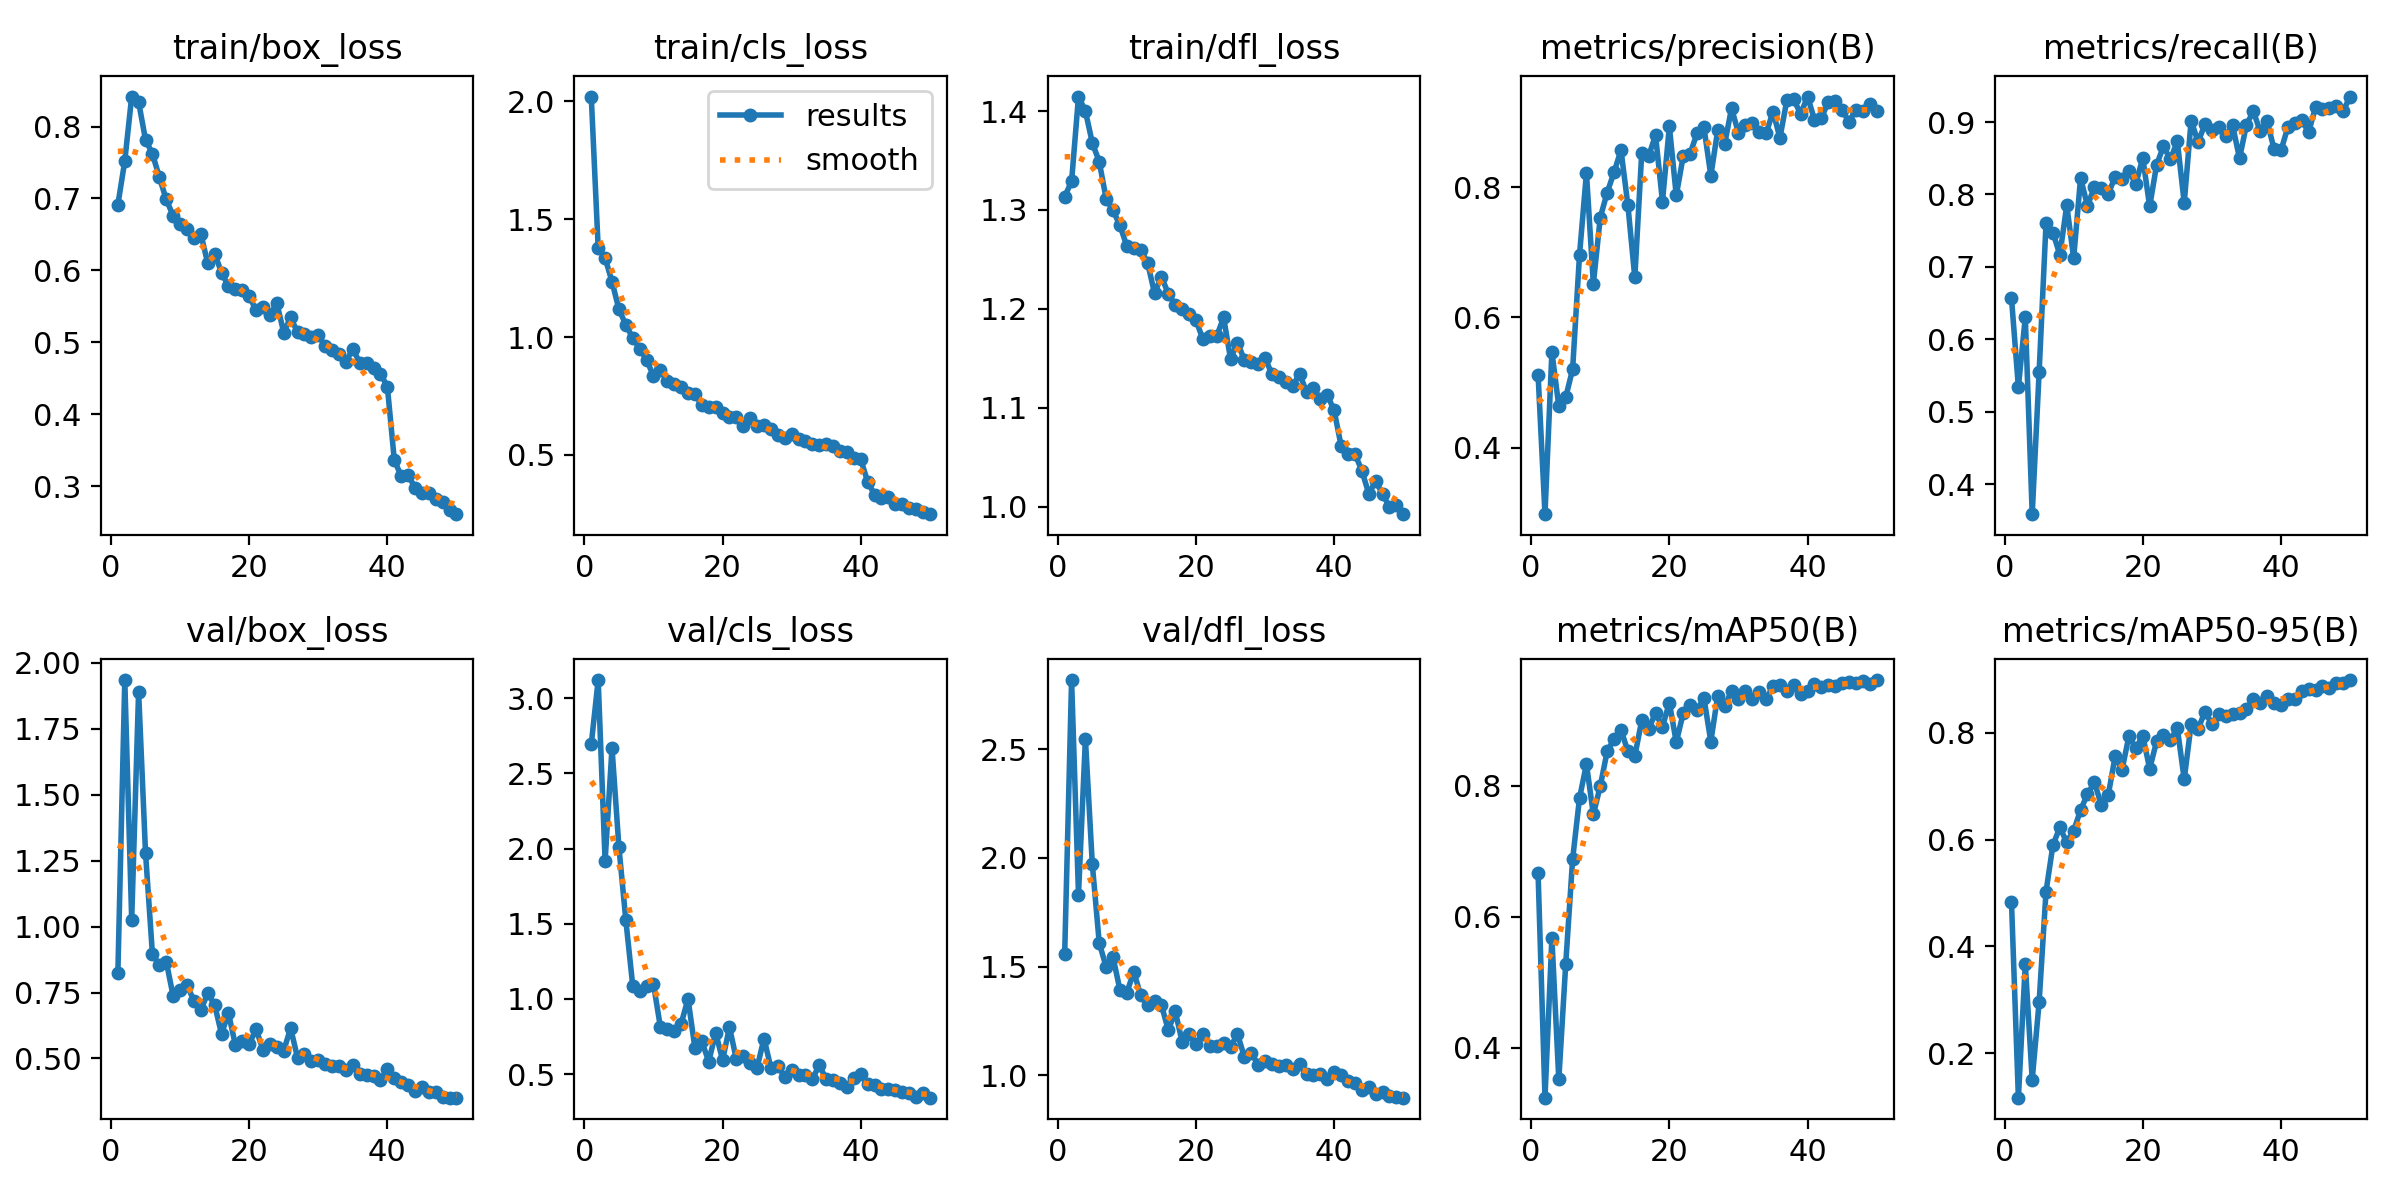

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(results.save_dir / "results.png"), width=900))

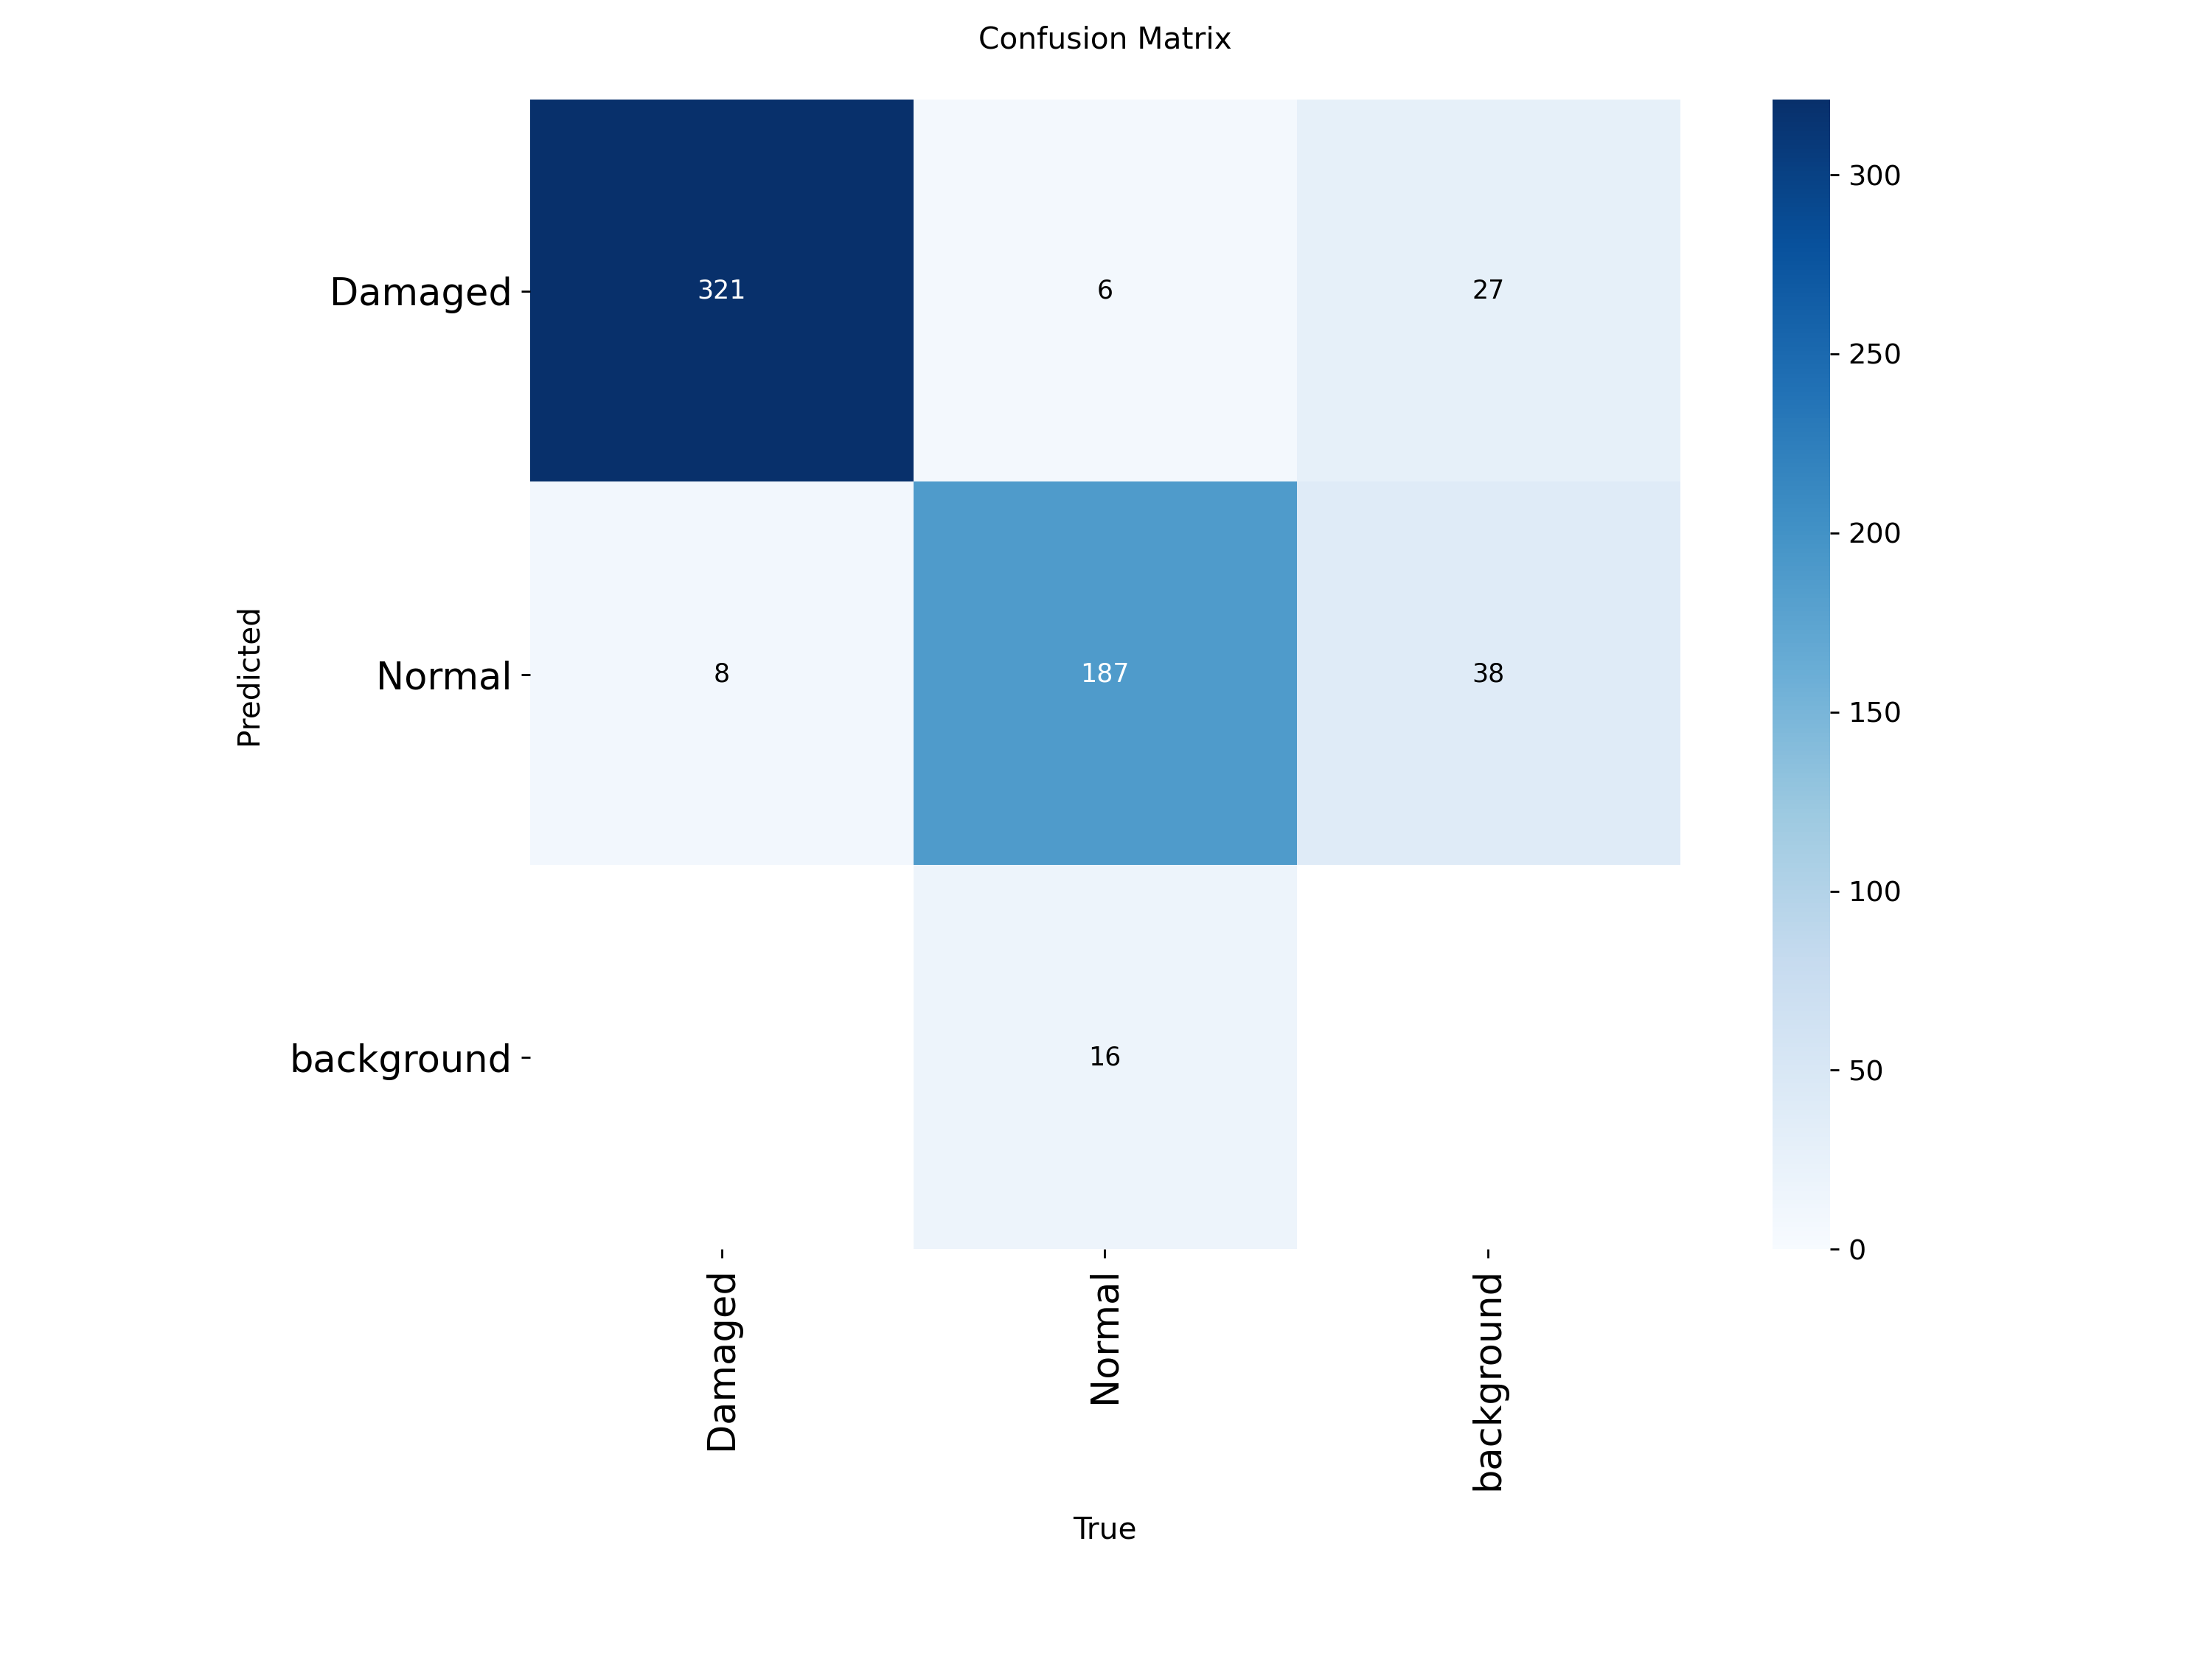

In [ ]:
# confusion matrix
display(Image(filename=str(results.save_dir / "confusion_matrix.png"), width=700))

Saving Screenshot 2026-07-01 124627.png to Screenshot 2026-07-01 124627 (5).png

image 1/1 /content/Screenshot 2026-07-01 124627 (5).png: 576x640 1 Damaged, 9.3ms
Speed: 2.7ms preprocess, 9.3ms inference, 1.5ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/runs/detect/damaged_package_runs/predict_custom-6
Hasil disimpan di: /content/runs/detect/damaged_package_runs/predict_custom-6/Screenshot 2026-07-01 124627 (5).jpg


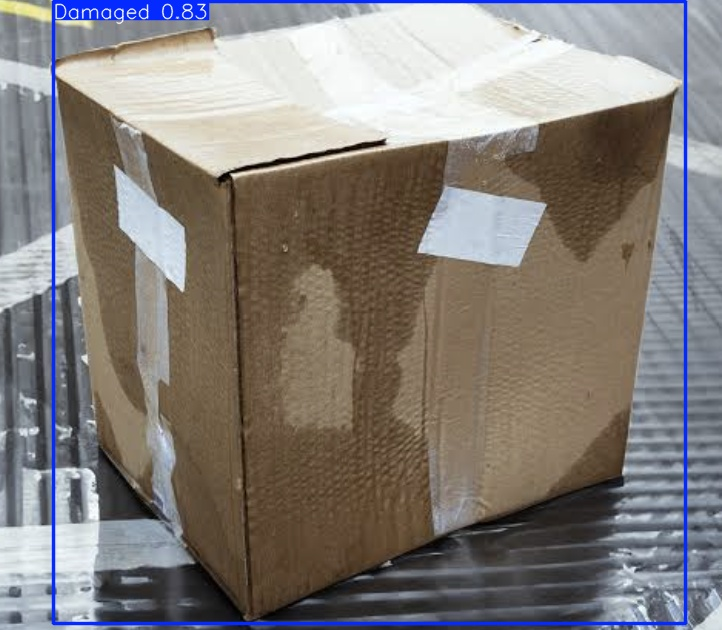

In [ ]:
from google.colab import files
from IPython.display import Image, display
import glob, os

uploaded = files.upload()

for filename in uploaded.keys():
    results = best_model.predict(
        source=filename,
        conf=0.25,
        save=True,
        project="damaged_package_runs",
        name="predict_custom"
    )

    save_dir = str(results[0].save_dir)
    saved_images = glob.glob(os.path.join(save_dir, "*"))

    for img_path in saved_images:
        print("Hasil disimpan di:", img_path)
        display(Image(filename=img_path, width=500))

Saving Screenshot 2026-07-01 131955.png to Screenshot 2026-07-01 131955.png

image 1/1 /content/Screenshot 2026-07-01 131955.png: 224x640 1 Damaged, 1 Normal, 51.4ms
Speed: 1.9ms preprocess, 51.4ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 640)
Results saved to /content/runs/detect/damaged_package_runs/predict_custom2
Hasil disimpan di: /content/runs/detect/damaged_package_runs/predict_custom2/Screenshot 2026-07-01 131955.jpg


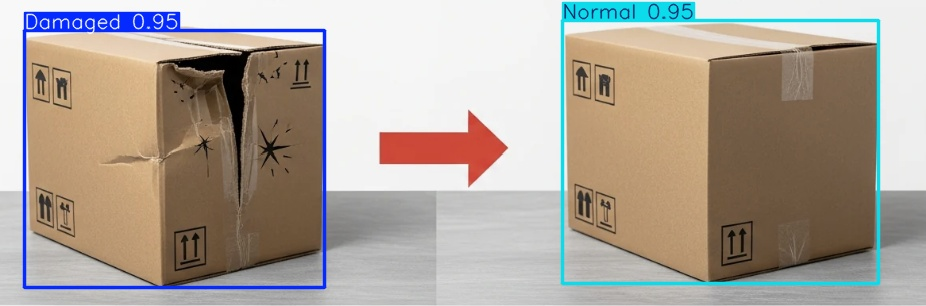

In [ ]:
from google.colab import files
from IPython.display import Image, display
import glob, os

uploaded = files.upload()

for filename in uploaded.keys():
    results = best_model.predict(
        source=filename,
        conf=0.25,
        save=True,
        project="damaged_package_runs",
        name="predict_custom2"
    )

    save_dir = str(results[0].save_dir)
    saved_images = glob.glob(os.path.join(save_dir, "*"))

    for img_path in saved_images:
        print("Hasil disimpan di:", img_path)
        display(Image(filename=img_path, width=500))

In [ ]:
from google.colab import files

print("Mengunduh dari:", best_model_path)
files.download(str(best_model_path))

Mengunduh dari: /content/runs/detect/damaged_package_runs/train-2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>